**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2025*

----

# Trabajo práctico entregable - parte 1

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_context('talk')

from sqlalchemy import create_engine, text

In [32]:
import plotly
plotly.__version__


'5.24.1'

In [33]:
melb_df_ = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df_[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar: df.to_sql() infiere tipos automáticamente, pero a veces los nombres de columnas como Date, Price o ID dan problemas si vienen con strings o valores nulos.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por ciudad.
    - cantidad de registros totales por barrio y ciudad.
    - Consulta con filtro: ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL  para obtener un resultado similar a lo realizado con Pandas en clase.  



In [34]:
# 1.1) Crear una base de datos en SQLite utilizando la libreria SQLalchemy. https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

engine = create_engine('sqlite:///rent_places.db')

melb_df = melb_df_.copy()


In [35]:
# 1.2) Ingestar los datos provistos en una tabla y el dataset generado en clase
# con datos de airbnb y sus precios por codigo postal en otra.

# Melbourn

melb_df.to_sql('melbourne', con=engine, if_exists='replace', index=False)

# Airbnb
from google.colab import drive
import os

file_id = "1vp8QHe4XiKDbHczoR3qC7udMJTcrNfHL"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Cargar el CSV desde el enlace público
airbnb_df_ = pd.read_csv(url)

airbnb_df = airbnb_df_.copy()

In [36]:
# 1.3) Validar tipos de columnas antes de guardar: df.to_sql() infiere tipos automáticamente,
# pero a veces los nombres de columnas como Date, Price o ID dan problemas si vienen con strings o valores nulos.

In [37]:
print("Melbourne DataFrame - Tipos inconsistentes por columna:\n")

for col in melb_df.columns:
    tipos = melb_df[col].map(type).value_counts()
    nulos = melb_df[col].isnull().sum()

    print(f"Columna: {col}")
    print(f"Tipos encontrados:")
    print(tipos)
    print(f"Valores nulos: {nulos}")
    print("-" * 40)


Melbourne DataFrame - Tipos inconsistentes por columna:

Columna: Suburb
Tipos encontrados:
Suburb
<class 'str'>    13580
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: Address
Tipos encontrados:
Address
<class 'str'>    13580
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: Rooms
Tipos encontrados:
Rooms
<class 'int'>    13580
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: Type
Tipos encontrados:
Type
<class 'str'>    13580
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: Price
Tipos encontrados:
Price
<class 'float'>    13580
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: Method
Tipos encontrados:
Method
<class 'str'>    13580
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: SellerG
Tipos encontrados:
SellerG
<class 's

Como se puede observar, los tipos de datos son consistentes por columnas, pero tienen muchos datos nulos.

Algunas de estas columnas que poseen valores nulos no me interesan, y por lo tanto las eliminaré:  <br>

-BuildingArea <br>
-YearBuilt <br>
-CouncilArea <br>

Otras las rellenaré con 0s:  <br>
-Car <br>

Por útimo, *Date* se pasará a datetime, y se reemplazaran los nulos con una fecha outlier fácilmente filtrable.

In [38]:
# Eliminar columnas que no interesan
melb_df.drop(columns=['BuildingArea', 'YearBuilt', 'CouncilArea'], inplace=True)

# Rellenar valores nulos con 0 en la columna Car
melb_df['Car'] = melb_df['Car'].fillna(0)

# Convertir la columna Date a tipo datetime
melb_df['Date'] = pd.to_datetime(melb_df['Date'], errors='coerce')

# Rellenar fechas nulas con una fecha arbitraria (por ejemplo 1900-01-01)
melb_df['Date'] = melb_df['Date'].fillna(pd.Timestamp("1900-01-01"))

# Corregimos el nombre de la columna
melb_df.rename(columns={'Longtitude': 'Longitude'}, inplace=True)

In [39]:
print("Airbnb DataFrame - Tipos inconsistentes por columna:\n")

for col in airbnb_df.columns:
    tipos = airbnb_df[col].map(type).value_counts()
    nulos = airbnb_df[col].isnull().sum()

    print(f"Columna: {col}")
    print(f"Tipos encontrados:")
    print(tipos)
    print(f"Valores nulos: {nulos}")
    print("-" * 40)


Airbnb DataFrame - Tipos inconsistentes por columna:

Columna: zipcode
Tipos encontrados:
zipcode
<class 'float'>    247
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: airbnb_price_mean
Tipos encontrados:
airbnb_price_mean
<class 'float'>    247
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: airbnb_record_count
Tipos encontrados:
airbnb_record_count
<class 'int'>    247
Name: count, dtype: int64
Valores nulos: 0
----------------------------------------
Columna: airbnb_weekly_price_mean
Tipos encontrados:
airbnb_weekly_price_mean
<class 'float'>    247
Name: count, dtype: int64
Valores nulos: 63
----------------------------------------
Columna: airbnb_monthly_price_mean
Tipos encontrados:
airbnb_monthly_price_mean
<class 'float'>    247
Name: count, dtype: int64
Valores nulos: 79
----------------------------------------


En este caso vemos que las variables que presentan los precios promedios tanto mensuales como semanales presentan algunos valores nulos. En este sentido es mejor eliminar la columna de datos semanales dado que con tener los datos mensuales ya podemos inferir comportamientos relacionados a la estacionalidad.<br> Además, reemplazaremos los valores nulos por el valor promedio del precio, para que los mismos no afecten demasiado en la distribución, y no perder demasiados datos.

In [40]:
# Eliminar columna semanal
airbnb_df.drop(columns=['airbnb_weekly_price_mean'], inplace=True)

# Reemplazar valores nulos en la columna mensual con su valor promedio (media)
promedio_mensual = airbnb_df['airbnb_monthly_price_mean'].mean()
airbnb_df['airbnb_monthly_price_mean'] = airbnb_df['airbnb_monthly_price_mean'].fillna(promedio_mensual)


In [41]:
# Verificamos nulos
print("Aún hay nulos?")
print(f"Melbourn: {np.sum(melb_df.isnull().sum())}")
print(f"Airbnb: {np.sum(airbnb_df.isnull().sum())}")

Aún hay nulos?
Melbourn: 0
Airbnb: 0


In [42]:
# Generamos base de datos para consultas
airbnb_df.to_sql('airbnb', con=engine, if_exists='replace', index=False)

melb_df.to_sql('melbourne', con=engine, if_exists='replace', index=False)

13580

In [43]:
melb_df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'Lattitude', 'Longitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [44]:
# 1.4) Implementar consultas en SQL que respondan con la siguiente información:

# Cantidad de registros totales por ciudad.
query_1 = """
SELECT 'Melbourne' AS ciudad, COUNT(*) AS cantidad_registros
FROM melbourne
"""
pd.read_sql_query(query_1, engine)

,ciudad,cantidad_registros
0,Melbourne,13580


In [45]:
# Cantidad de registros totales por barrio y ciudad.
# Tomo los suburbios dado que me segmenta a la ciudad de manera más
# fina de lo que lo hacen las regiones
query_2 = """
SELECT Suburb AS barrio, Regionname AS ciudad, COUNT(*) AS cantidad_registros
FROM melbourne
GROUP BY Suburb, Regionname
"""
pd.read_sql_query(query_2, engine)

,barrio,ciudad,cantidad_registros
0,Abbotsford,Northern Metropolitan,56
1,Aberfeldie,Western Metropolitan,44
2,Airport West,Western Metropolitan,67
3,Albanvale,Western Metropolitan,6
4,Albert Park,Southern Metropolitan,69
...,...,...,...
309,Wonga Park,Eastern Victoria,1
310,Wyndham Vale,Western Metropolitan,4
311,Yallambie,Northern Metropolitan,24
312,Yarra Glen,Northern Victoria,1


In [46]:
# ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?
query_3 = """
SELECT 'Melbourne' AS ciudad, COUNT(*) AS cantidad_propiedades
FROM melbourne
WHERE Rooms > 2
"""
pd.read_sql_query(query_3, engine)

,ciudad,cantidad_propiedades
0,Melbourne,9251


In [47]:
# ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?
query_4 = """
SELECT Type, 'Melbourne' AS ciudad, AVG(Price) AS precio_promedio
FROM melbourne
GROUP BY Type
"""
df_avg_price = pd.read_sql_query(query_4, engine)

# Imprimir precios
print("Precio promedio por tipo de propiedad:\n")
for _, row in df_avg_price.iterrows():
    print(f"Tipo: {row['Type']} - Precio promedio: ${row['precio_promedio']:,.0f}")

Precio promedio por tipo de propiedad:

Tipo: h - Precio promedio: $1,242,665
Tipo: t - Precio promedio: $933,735
Tipo: u - Precio promedio: $605,127


In [48]:
# Mostrá el top 5 barrios con propiedades más caras en promedio.
query_5 = """
SELECT Suburb AS barrio, AVG(Price) AS precio_promedio
FROM melbourne
GROUP BY Suburb
ORDER BY precio_promedio DESC
LIMIT 5
"""

df_top5 = pd.read_sql_query(query_5, engine)

# Imprimir precios
print("Top 5 barrios con propiedades más caras en promedio:\n")
for _, row in df_top5.iterrows():
    barrio = row['barrio']
    precio = row['precio_promedio']
    print(f"Barrio: {barrio:<25} - Precio promedio: ${precio:,.0f}")


Top 5 barrios con propiedades más caras en promedio:

Barrio: Kooyong                   - Precio promedio: $2,185,000
Barrio: Canterbury                - Precio promedio: $2,180,241
Barrio: Middle Park               - Precio promedio: $2,082,529
Barrio: Albert Park               - Precio promedio: $1,941,355
Barrio: Brighton                  - Precio promedio: $1,930,158


In [49]:
# 1.5) Combinar los datasets de ambas tablas ingestadas utilizando el
# comando JOIN de SQL para obtener un resultado similar a lo realizado con Pandas en clase.

query_join = """
SELECT
    m.Suburb,
    m.Regionname,
    m.Postcode,
    m.Type,
    m.Rooms,
    m.Price,
    m.Lattitude,
    m.Longitude,
    a.airbnb_price_mean,
    a.airbnb_record_count,
    a.airbnb_monthly_price_mean
FROM melbourne m
LEFT JOIN airbnb a
ON CAST(m.Postcode AS INTEGER) = CAST(a.zipcode AS INTEGER)
"""

df_joined = pd.read_sql_query(query_join, engine)
df_joined.head()


,Suburb,Regionname,Postcode,Type,Rooms,Price,Lattitude,Longitude,airbnb_price_mean,airbnb_record_count,airbnb_monthly_price_mean
0,Abbotsford,Northern Metropolitan,3067.0,h,2,1480000.0,-37.7996,144.9984,130.624031,258.0,2187.032258
1,Abbotsford,Northern Metropolitan,3067.0,h,2,1035000.0,-37.8079,144.9934,130.624031,258.0,2187.032258
2,Abbotsford,Northern Metropolitan,3067.0,h,3,1465000.0,-37.8093,144.9944,130.624031,258.0,2187.032258
3,Abbotsford,Northern Metropolitan,3067.0,h,3,850000.0,-37.7969,144.9969,130.624031,258.0,2187.032258
4,Abbotsford,Northern Metropolitan,3067.0,h,4,1600000.0,-37.8072,144.9941,130.624031,258.0,2187.032258


Esto hizo un LEFT JOIN, lo que significa que se conservaron todas las propiedades de melbourne, y se agregaron los datos de airbnb solo si existia coincidencia por código postal.

## Ejercicio 2 - Pandas:

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2.  Mostrar la dispersión o distribución de las columnas seleccionadas.
 3.  Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás



2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?

In [50]:
# 2.1)

columnas_relevantes = [
    'Rooms',                      # Cantidad de habitaciones
    'Type',                       # Tipo de propiedad
    'Regionname',                # Zona
    'Suburb',                    # Barrio
    'airbnb_price_mean',         # Precio medio de Airbnb
    'airbnb_monthly_price_mean', # Precio mensual de Airbnb
    'Postcode',                  # Código postal
    'Lattitude',                 # Latitud para graficar
    'Longitude'                  # Longitud para graficar
]
df_modelo = df_joined[columnas_relevantes + ['Price']]

# Columnas no seleccionadas:
# Date: Suponemos baja inflación.
# Car, Bathroom, Bedroom2, etc.: Features muy específicas
# airbnb_record_count: no es relevante si no es presentada junto con la zona


In [51]:
# 2.1.1) Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
porcentaje_filas_con_nulos = (df_modelo.isnull().any(axis=1).mean()) * 100
print(f"Porcentaje de filas con al menos un valor faltante: {porcentaje_filas_con_nulos:.2f}%")


Porcentaje de filas con al menos un valor faltante: 0.15%


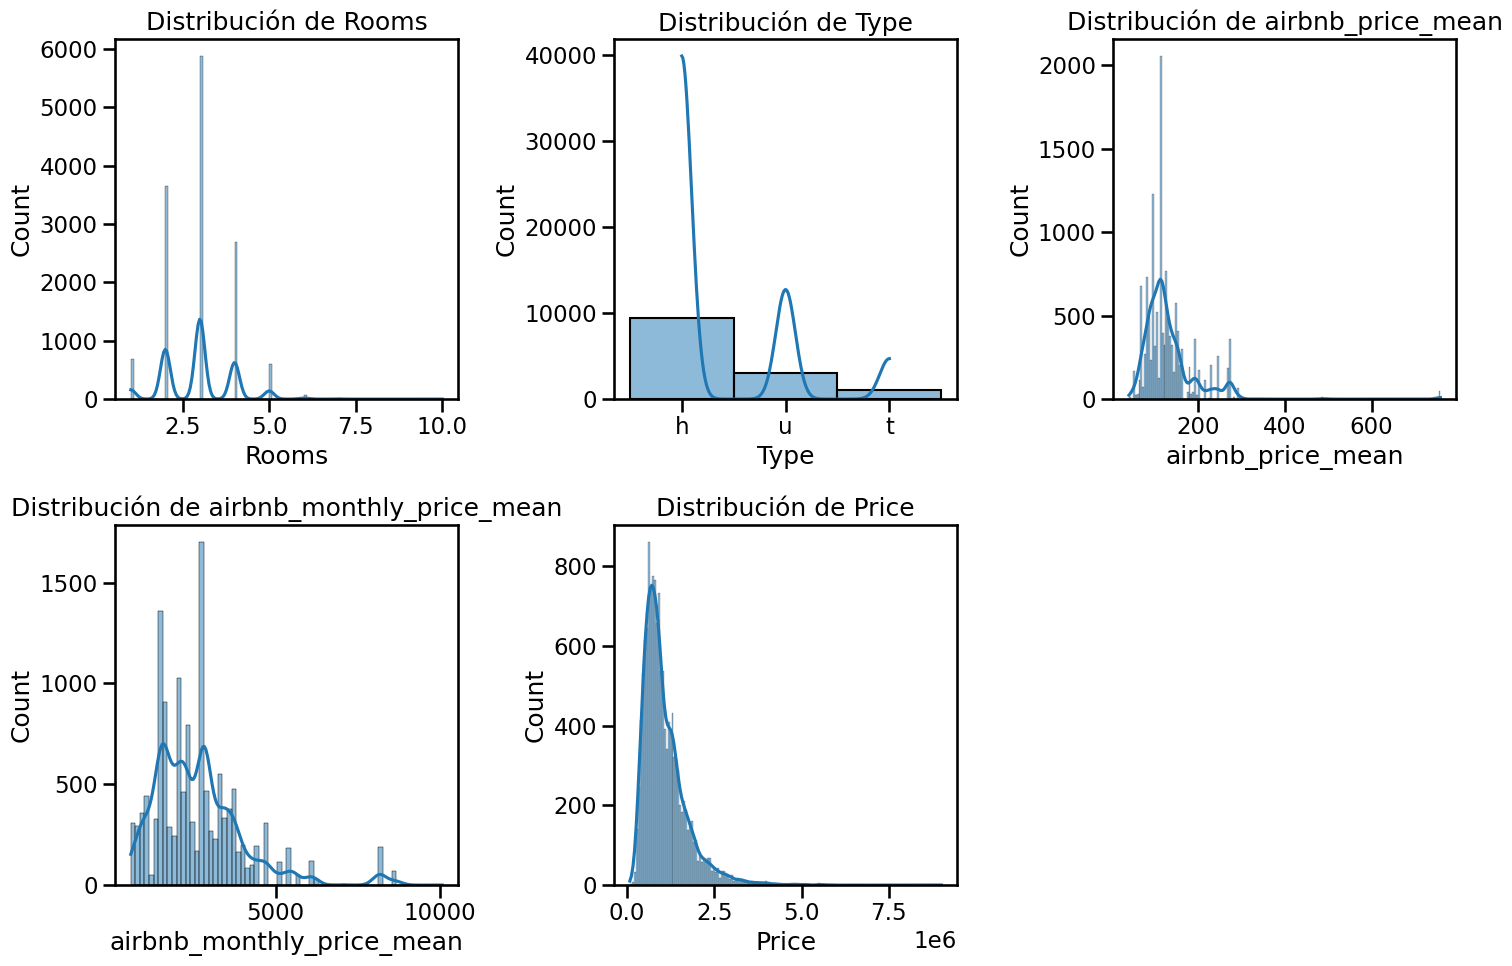

In [52]:
# 2.1.2) Mostrar la dispersión o distribución de las columnas seleccionadas.

# Columnas interesantes respecto a la distribución
columnas_numericas = ['Rooms','Type', 'airbnb_price_mean', 'airbnb_monthly_price_mean', 'Price']

plt.figure(figsize=(15,10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_modelo[col].dropna(), kde=True)
    plt.title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


La distribución por regiones sería mejor mostrarla en un mapa.

In [53]:
# 2.1.3) Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.

# Calcular Q1, Q3 e IQR
q01 = df_modelo['Price'].quantile(0.01) # precio por encima del 1% de los precios más bajos
q1 = df_modelo['Price'].quantile(0.25)  # precio por encima del 25% de los precios más bajos
q3 = df_modelo['Price'].quantile(0.75)  # precio por encima del 75% de los precios más bajos
iqr = q3 - q1

# Límites inferiores y superiores (Tukey)
lower_limit = max(q01, q1 - 1.5 * iqr) # Puede llegar a dar negativo

upper_limit = q3 + 1.5 * iqr

print(f"Límite inferior: ${lower_limit:,.0f}")
print(f"Límite superior: ${upper_limit:,.0f}")

# Filtrar dataset eliminando outliers
df_filtrado = df_modelo[(df_modelo['Price'] >= lower_limit) & (df_modelo['Price'] <= upper_limit)]


Límite inferior: $300,000
Límite superior: $2,350,000


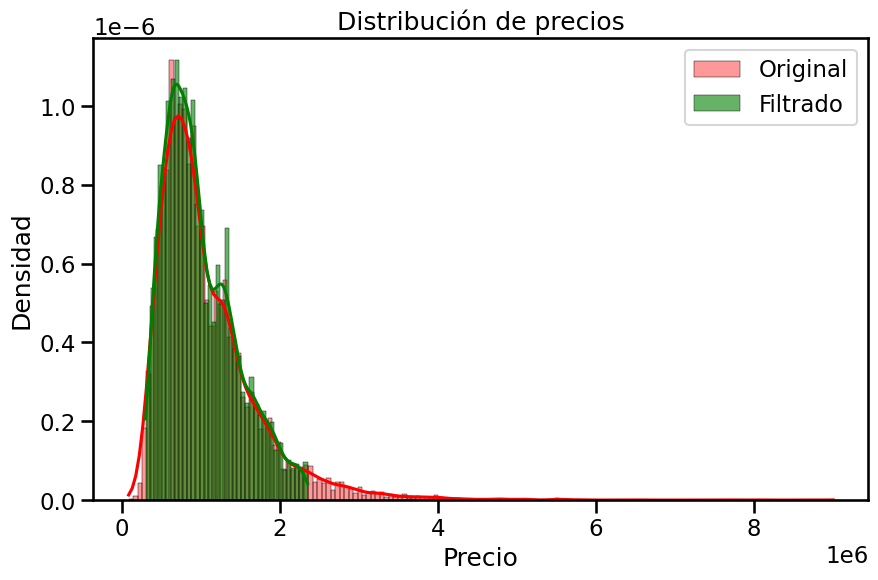

In [54]:
# 2.1.4) Mostrar visualmente los valores extremos que eliminás
plt.figure(figsize=(10, 6))

sns.histplot(df_modelo['Price'], color='red', label='Original', kde=True, stat='density', alpha=0.4)
sns.histplot(df_filtrado['Price'], color='green', label='Filtrado', kde=True, stat='density', alpha=0.6)

plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Densidad")
plt.legend()
plt.show()


In [55]:
# 2.2) Agregar información adicional respectiva al entorno de una propiedad a partir del conjunto de datos de AirBnB utilizado en el práctico.
# 2.2.1) Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna price,
# o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.

# Agrupamos por zipcode y calculamos la mediana de los precios
airbnb_agregado = airbnb_df.groupby('zipcode').agg(
    airbnb_price_median=('airbnb_price_mean', 'median'),
    airbnb_monthly_price_median=('airbnb_monthly_price_mean', 'median'),
    airbnb_listing_count=('airbnb_record_count', 'sum')
).reset_index()


In [56]:
# 2.2.2) Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una
# cantidad mínima de registros (a elección) como para que la información agregada sea relevante.

# Filtrar por cantidad mínima de registros
airbnb_agregado = airbnb_agregado[airbnb_agregado['airbnb_listing_count'] >= 90]

# Unir con el dataframe de propiedades
df_enriquecido = df_filtrado.merge(
    airbnb_agregado,
    left_on='Postcode',
    right_on='zipcode',
    how='left'
)

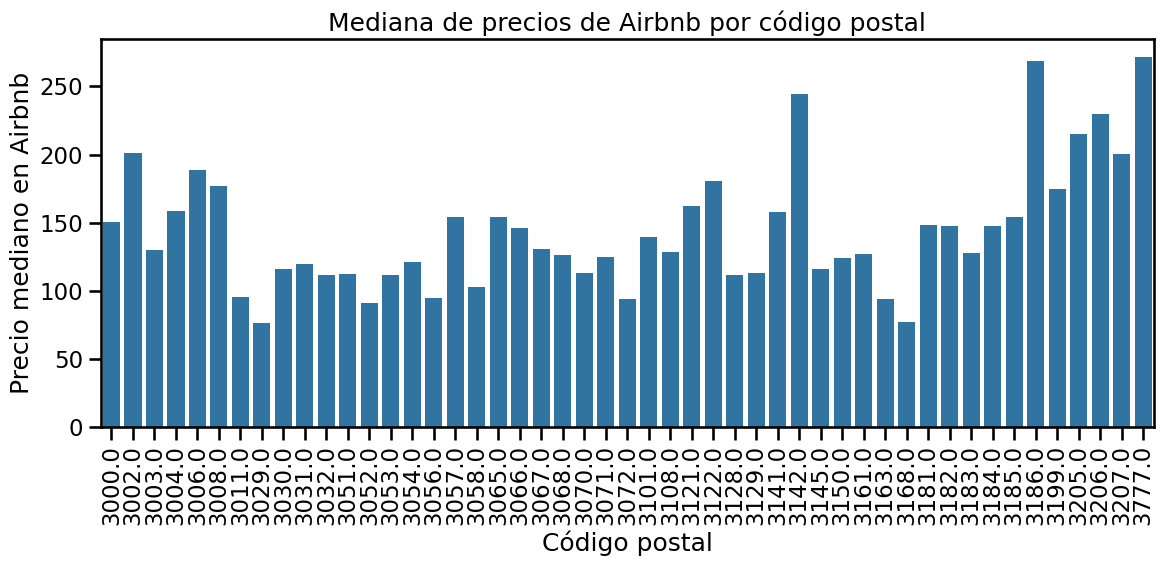

In [57]:
# 2.2.3) Mostrar un gráfico zipcode vs airbnb_price_median

plt.figure(figsize=(12, 6))
sns.barplot(x='zipcode', y='airbnb_price_median', data=airbnb_agregado.sort_values('airbnb_price_median', ascending=False))
plt.xticks(rotation=90)
plt.title("Mediana de precios de Airbnb por código postal")
plt.xlabel("Código postal")
plt.ylabel("Precio mediano en Airbnb")
plt.tight_layout()
plt.show()


### 2.2.4) Otras variables que podrían usarse para combinar los datasets

#### 1. `Suburb` (barrio)
- Si ambos datasets tienen nombres de barrios (suburbios), se podrían cruzar por esa variable.

#### 2. Coordenadas geográficas
- Si se dispone de latitud y longitud de las propiedades (como en `melb_df`), se pueden utilizar para mejorar la relación entre los datos mediante proximidad.



### 2.2.5) Si las coordenadas geoespaciales estuvieran disponibles, ¿cómo las usarías?

Si las coordenadas estuvieran disponibles, considero que sería muy valioso transformar el **DataFrame** en un **GeoDataFrame**. Es decir, un DataFrame que permite representar la posición de los puntos estudiados sobre un mapa. Esto aportaría mucho valor y facilitaría el uso de la base de datos tanto para programadores como para usuarios, especialistas y otros perfiles interesados en el análisis geoespacial.


In [63]:
# Instalar dependencias necesarias para mapas interactivos en geopandas
!pip install folium mapclassify --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.4 MB/s eta 0:00:00


In [64]:
# Crear un GeoDataFrame a partir de latitud y longitud en Melbourne
import geopandas as gpd
from shapely.geometry import Point

# Eliminar filas con coordenadas faltantes
df_modelo = df_modelo.dropna(subset=['Lattitude', 'Longitude'])

# Crear la geometría a partir de las coordenadas
geometry = [Point(xy) for xy in zip(df_modelo['Longitude'], df_modelo['Lattitude'])]
gdf = gpd.GeoDataFrame(df_modelo, geometry=geometry, crs="EPSG:4326")

# Mostrar mapa
gdf.explore()

## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

In [59]:
# Guardar como CSV
df_enriquecido.to_csv("dataset_final.csv", index=False)

from google.colab import files
files.download("dataset_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Ejercicios opcionales:

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)